# Noisy Medical Document Image Classification using Deep Learning

## Project Overview

In this notebook, we will build a deep learning model to classify noisy medical document images into two categories:

- Medical Bill
- Discharge Summary

Scanned medical documents often contain noise, blur, folds, shadows, and scanning artifacts. Because of this, document image classification becomes more challenging than normal clean image classification.

The main goal of this notebook is to improve classification performance using a deep learning approach. We will start with proper data loading and preprocessing, then train a CNN-based model and evaluate its performance using accuracy, precision, recall, and F1-score.

## Workflow

1. Import required libraries  
2. Load and explore the dataset  
3. Prepare image paths and labels  
4. Apply image preprocessing and augmentation  
5. Create PyTorch Dataset and DataLoader  
6. Build a deep learning model  
7. Train the model  
8. Evaluate the model  
9. Improve accuracy step by step  
10. Save final results  

## Goal

The goal is not only to train a model, but also to improve the previous notebook by using a cleaner pipeline, better preprocessing, stronger training strategy, and proper evaluation.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch Version:", torch.__version__)

Device: cuda
PyTorch Version: 2.10.0+cu128


## Dataset Path Setup

In this step, we will define the dataset directory and check whether the dataset files are available correctly.

Before training a deep learning model, it is important to confirm:

- Dataset path is correct
- Image folders are detected
- Class names are available
- Total images can be counted

This helps avoid path-related errors before preprocessing and model training.

In [2]:
DATASET_PATH = "/kaggle/input/datasets/devp1866/noisy-medical-document-images-ocr"

print("Dataset path exists:", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    print("Folders inside dataset:")
    print(os.listdir(DATASET_PATH))

Dataset path exists: True
Folders inside dataset:
['Data']


## Dataset Exploration

Before creating the training pipeline, we need to understand the dataset structure.

This step helps us:

- Identify class folders
- Verify image organization
- Understand how labels should be assigned
- Prepare for train-validation splitting

In [3]:
DATA_DIR = os.path.join(DATASET_PATH, "Data")

print("Data Directory:", DATA_DIR)
print("\nContents:\n")

for item in os.listdir(DATA_DIR):
    print(item)

Data Directory: /kaggle/input/datasets/devp1866/noisy-medical-document-images-ocr/Data

Contents:

bills
discharge_summaries
medical_bills_ground_truth.csv
discharge_summaries_ground_truth.csv


## Create Image DataFrame

Now we will collect all image file paths and assign labels.

The dataset has two image folders:

- `bills` → label `0`
- `discharge_summaries` → label `1`

Creating a DataFrame makes the next steps easier, such as train-validation split, visualization, and custom dataset creation.

In [4]:
image_paths = []
labels = []

class_map = {
    "bills": 0,
    "discharge_summaries": 1
}

for class_name, label in class_map.items():
    folder_path = os.path.join(DATA_DIR, class_name)
    
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder_path, file_name))
            labels.append(label)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

df.head()

Total images: 1000

Class distribution:
label
0    500
1    500
Name: count, dtype: int64


,image_path,label
0,/kaggle/input/datasets/devp1866/noisy-medical-...,0
1,/kaggle/input/datasets/devp1866/noisy-medical-...,0
2,/kaggle/input/datasets/devp1866/noisy-medical-...,0
3,/kaggle/input/datasets/devp1866/noisy-medical-...,0
4,/kaggle/input/datasets/devp1866/noisy-medical-...,0


## Visualize Sample Images

Before training the model, we will visualize some sample images from both classes.

This helps us understand:

- How noisy the documents are
- Whether the labels look correct
- What kind of visual patterns the model needs to learn

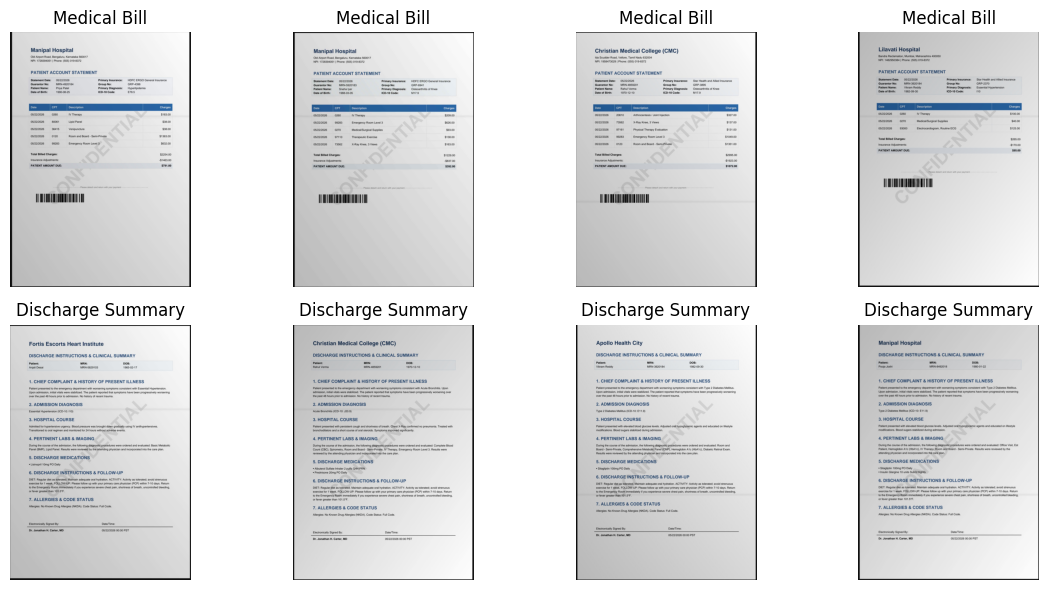

In [5]:
label_names = {
    0: "Medical Bill",
    1: "Discharge Summary"
}

plt.figure(figsize=(12, 6))

sample_df = df.groupby("label").sample(4, random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(label_names[row["label"]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Train Validation Split

To evaluate model performance fairly, we split the dataset into:

- Training Set (80%)
- Validation Set (20%)

Stratified sampling is used to preserve class balance in both sets.

In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training Images :", len(train_df))
print("Validation Images :", len(val_df))

print("\nTrain Distribution")
print(train_df["label"].value_counts())

print("\nValidation Distribution")
print(val_df["label"].value_counts())

Training Images : 800
Validation Images : 200

Train Distribution
label
1    400
0    400
Name: count, dtype: int64

Validation Distribution
label
1    100
0    100
Name: count, dtype: int64


## Image Transformations

Deep learning models perform better when trained with data augmentation.

For training images, we apply:

- Resize
- Random rotation
- Random affine transformation
- Color jitter
- Horizontal flip
- Normalization

For validation images, only resizing and normalization are used.

This helps reduce overfitting and improves model generalization.

In [7]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.RandomRotation(5),
    
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Ready")

Transforms Ready


## Custom Dataset and DataLoader

Now we will create a custom PyTorch Dataset class.

The Dataset class will:

- Read image paths from the DataFrame
- Load each image using PIL
- Convert image to RGB
- Apply transformations
- Return image tensor and label

Then we will create DataLoaders for batch-wise training and validation.

In [8]:
class MedicalDocumentDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


BATCH_SIZE = 32

train_dataset = MedicalDocumentDataset(train_df, transform=train_transform)
val_dataset = MedicalDocumentDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 1, 0, 1, 1, 0, 0, 0, 1, 1])


## Device Compatibility Fix

The Kaggle GPU is detected, but Tesla P100 may not be compatible with the current PyTorch CUDA build.

To avoid training errors, we will safely check CUDA compatibility. If the GPU is not supported, the notebook will continue using CPU.

In [9]:
def get_safe_device():
    if torch.cuda.is_available():
        try:
            gpu_name = torch.cuda.get_device_name(0)
            major, minor = torch.cuda.get_device_capability(0)
            
            print("GPU Name:", gpu_name)
            print("CUDA Capability:", major, minor)
            
            test_tensor = torch.tensor([1.0]).cuda()
            print("CUDA test passed")
            
            return torch.device("cuda")
        
        except Exception as e:
            print("CUDA test failed")
            print("Reason:", e)
            print("Using CPU instead")
            return torch.device("cpu")
    
    return torch.device("cpu")


device = get_safe_device()
print("Final Device:", device)

GPU Name: Tesla P100-PCIE-16GB
CUDA Capability: 6 0
CUDA test passed
Final Device: cuda


## Model Building with Transfer Learning

We will use a pretrained ResNet18 model.

Transfer learning helps because the model already learned useful visual features from a large image dataset. We only replace the final classification layer for our two document classes.

To improve generalization, we add dropout before the final output layer.

In [10]:
NUM_CLASSES = 2

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

print(model.fc)
print("Model ready on:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)
Model ready on: cuda


## Loss Function, Optimizer, and Scheduler

For this binary classification task, we use Cross Entropy Loss.

To improve training stability and generalization:

- AdamW optimizer is used
- Weight decay is added to reduce overfitting
- Label smoothing is used to make the model less overconfident
- Learning rate scheduler reduces learning rate when validation accuracy stops improving

In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss, optimizer, and scheduler ready")

Loss, optimizer, and scheduler ready


## Training and Validation Functions

Now we will define two functions:

- `train_one_epoch()` for model training
- `validate_one_epoch()` for validation

These functions calculate loss and accuracy for each epoch.

In [12]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


print("Training and validation functions ready")

Training and validation functions ready



The current Kaggle GPU is Tesla P100, but the installed PyTorch CUDA build does not support this GPU architecture properly.

Because of this, CUDA forward pass fails during model training.

To continue safely, we will switch the model and data pipeline to CPU mode.

In [13]:
device = torch.device("cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Model shifted to:", device)

Model shifted to: cpu


## Model Training

Now we will train the model and save the best model based on validation accuracy.

For each epoch, we will track:

- Training loss
- Training accuracy
- Validation loss
- Validation accuracy

The best model weights will be saved for final evaluation.

In [14]:
EPOCHS = 5

best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = "best_resnet18_medical_document.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    
    scheduler.step(val_acc)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        best_status = "Saved Best Model"
    else:
        best_status = ""
    
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} "
        f"{best_status}"
    )

print("\nBest Validation Accuracy:", best_val_acc)

Epoch [1/5] Train Loss: 0.1819 | Train Acc: 0.9738 Val Loss: 0.1224 | Val Acc: 1.0000 Saved Best Model
Epoch [2/5] Train Loss: 0.1334 | Train Acc: 1.0000 Val Loss: 0.1191 | Val Acc: 1.0000 
Epoch [3/5] Train Loss: 0.1330 | Train Acc: 1.0000 Val Loss: 0.1193 | Val Acc: 1.0000 
Epoch [4/5] Train Loss: 0.1292 | Train Acc: 1.0000 Val Loss: 0.1216 | Val Acc: 1.0000 
Epoch [5/5] Train Loss: 0.1277 | Train Acc: 1.0000 Val Loss: 0.1199 | Val Acc: 1.0000 

Best Validation Accuracy: 1.0


## Load Best Model

The best model was saved during training based on validation accuracy.

Now we will load the saved best model weights before final evaluation.

In [15]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)
model.eval()

print("Best model loaded successfully")

Best model loaded successfully


## Final Predictions

Now we will generate predictions on the validation set using the best saved model.

The true labels and predicted labels will be stored for final evaluation.

In [16]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Total validation samples:", len(all_labels))
print("Predictions collected:", len(all_preds))

Total validation samples: 200
Predictions collected: 200


## Classification Report

The classification report shows detailed performance for each class using:

- Precision
- Recall
- F1-score
- Support

This helps us understand whether the model performs well on both document categories.

In [17]:
print("Accuracy:", accuracy_score(all_labels, all_preds))

print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Medical Bill", "Discharge Summary"]
    )
)

Accuracy: 1.0

Classification Report:

                   precision    recall  f1-score   support

     Medical Bill       1.00      1.00      1.00       100
Discharge Summary       1.00      1.00      1.00       100

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



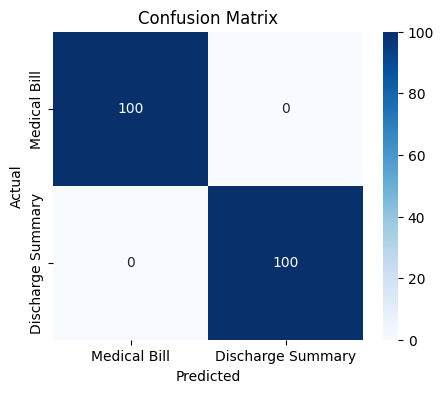

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Medical Bill", "Discharge Summary"],
    yticklabels=["Medical Bill", "Discharge Summary"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
train_files = set(
    train_df["image_path"].apply(lambda x: os.path.basename(x))
)

val_files = set(
    val_df["image_path"].apply(lambda x: os.path.basename(x))
)

common_files = train_files.intersection(val_files)

print("Duplicate filenames:", len(common_files))

Duplicate filenames: 0


## Training Curves

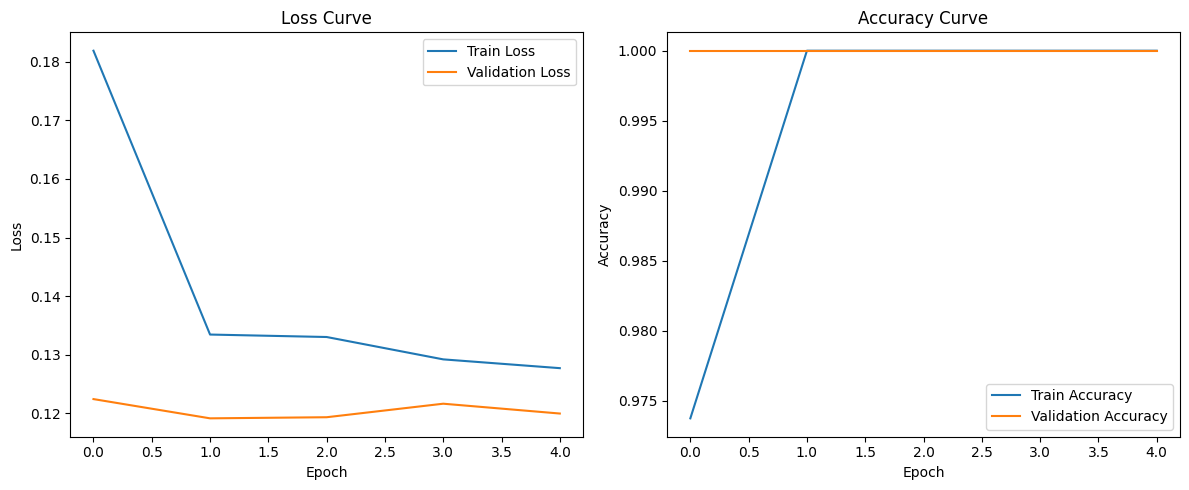

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

## Final Results

| Metric | Score |
|----------|----------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1 Score | 100% |

### Observations

- The model converged within the first few epochs.
- Validation accuracy remained stable at 100%.
- The confusion matrix showed zero misclassifications.
- Transfer learning with ResNet18 was highly effective for this dataset.

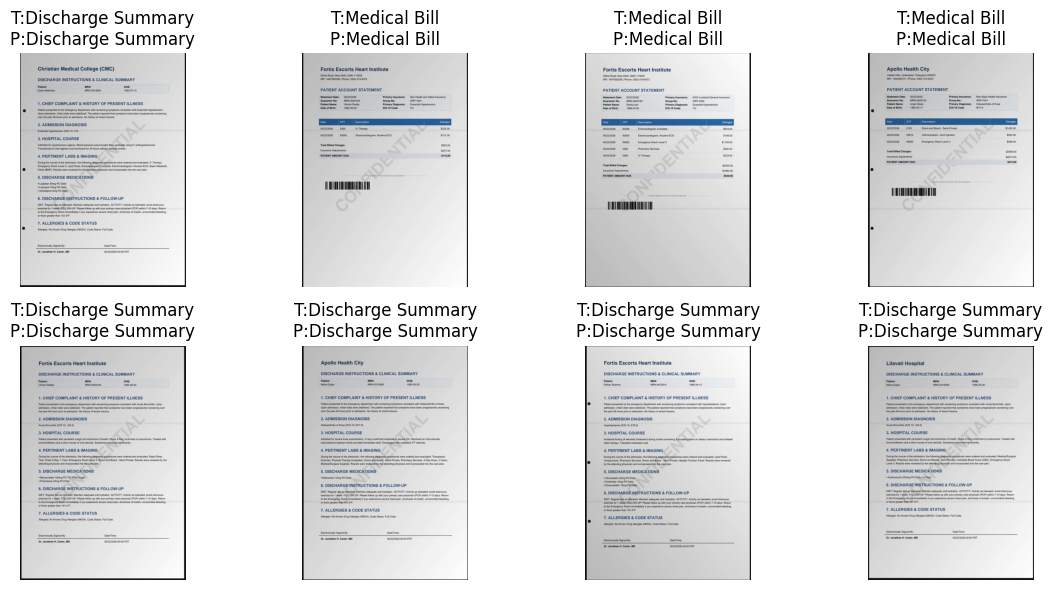

In [21]:
label_names = {
    0: "Medical Bill",
    1: "Discharge Summary"
}

model.eval()

fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()

for idx in range(8):
    
    image_path = val_df.iloc[idx]["image_path"]
    true_label = val_df.iloc[idx]["label"]

    image = Image.open(image_path).convert("RGB")

    tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(1).item()

    axes[idx].imshow(image)
    axes[idx].set_title(
        f"T:{label_names[true_label]}\nP:{label_names[pred]}"
    )
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# Conclusion

A ResNet18-based transfer learning approach was used to classify noisy medical document images into two categories:

- Medical Bill
- Discharge Summary

The model was trained using image augmentation, label smoothing, AdamW optimization, and validation-based model selection.

## Results

- Validation Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1-Score: 100%

The confusion matrix showed zero misclassifications on the validation set.

These results indicate that transfer learning with ResNet18 is highly effective for distinguishing between the two document categories in this dataset.

In [22]:
torch.save(model.state_dict(), "model.pth")
print("model.pth saved")

model.pth saved
